In [2]:
import os
import shutil

SOURCE_DIR = r"dataset"
DEST_IMG = r"dataset_all\images_all"
DEST_XML = r"dataset_all\xml_all"

os.makedirs(DEST_IMG, exist_ok=True)
os.makedirs(DEST_XML, exist_ok=True)

for root, dirs, files in os.walk(SOURCE_DIR):
    for file in files:
        if file.endswith(".jpg") or file.endswith(".png"):
            shutil.copy(os.path.join(root, file), DEST_IMG)

        if file.endswith(".xml"):
            shutil.copy(os.path.join(root, file), DEST_XML)

print("All files collected ✅")

All files collected ✅


In [3]:
import os
import shutil

SOURCE_DIR = r"dataset"
DEST_IMG = r"dataset_all\\images_all"
DEST_XML = r"dataset_all\\xml_all"

os.makedirs(DEST_IMG, exist_ok=True)
os.makedirs(DEST_XML, exist_ok=True)

img_count = 0
xml_count = 0

for root, dirs, files in os.walk(SOURCE_DIR):
    for file in files:

        full_path = os.path.join(root, file)

        if file.lower().endswith((".jpg", ".png", ".jpeg")):
            shutil.copy(full_path, os.path.join(DEST_IMG, file))
            img_count += 1

        elif file.lower().endswith(".xml"):
            shutil.copy(full_path, os.path.join(DEST_XML, file))
            xml_count += 1

print("Images copied:", img_count)
print("XMLs copied:", xml_count)

Images copied: 2140
XMLs copied: 2137


In [5]:
import os

base = r"dataset"

print("Dataset exists:", os.path.exists(base))
print("Inside dataset folder:")
print(os.listdir(base))

Dataset exists: True
Inside dataset folder:
['google_images', 'images_all', 'State-wise_OLX', 'video_images', 'xml_all']


In [6]:
import os

images = os.listdir(r"dataset_all\images_all")
xmls = os.listdir(r"dataset_all\xml_all")

print("Total Images:", len(images))
print("Total XMLs:", len(xmls))

Total Images: 1698
Total XMLs: 1697


In [9]:
import os

XML_DIR = r"dataset_all\xml_all"
IMG_DIR = r"dataset_all\images_all"
LABEL_DIR = r"dataset_all\labels_all"

os.makedirs(LABEL_DIR, exist_ok=True)

In [12]:
import xml.etree.ElementTree as ET
import os

def convert_xml_to_yolo(xml_path, label_path, img_dir):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text
    img_path = os.path.join(img_dir, filename)

    # Skip if image not found
    if not os.path.exists(img_path):
        return

    # Get image size
    size = root.find("size")
    w = int(size.find("width").text)
    h = int(size.find("height").text)

    with open(label_path, "w") as f:
        for obj in root.findall("object"):
            class_name = obj.find("name").text

            # ONLY if your class is license_plate
            if class_name != "license_plate":
                continue

            class_id = 0  # only one class

            bbox = obj.find("bndbox")
            xmin = int(bbox.find("xmin").text)
            ymin = int(bbox.find("ymin").text)
            xmax = int(bbox.find("xmax").text)
            ymax = int(bbox.find("ymax").text)

            # Convert to YOLO format
            x_center = ((xmin + xmax) / 2) / w
            y_center = ((ymin + ymax) / 2) / h
            width = (xmax - xmin) / w
            height = (ymax - ymin) / h

            f.write(f"{class_id} {x_center} {y_center} {width} {height}\n")


# RUN FOR ALL XMLs
for xml_file in os.listdir(XML_DIR):
    xml_path = os.path.join(XML_DIR, xml_file)
    label_path = os.path.join(LABEL_DIR, xml_file.replace(".xml", ".txt"))

    convert_xml_to_yolo(xml_path, label_path, IMG_DIR)

print(" XML → YOLO conversion done")

 XML → YOLO conversion done


In [13]:
print(len(os.listdir(LABEL_DIR)))
print(len(os.listdir(IMG_DIR)))

1695
1698


In [15]:
import os
import random
import shutil

IMG_DIR = r"dataset_all\images_all"
LABEL_DIR = r"dataset_all\labels_all"

BASE_DIR = r"dataset_all"

for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(BASE_DIR, "images", split), exist_ok=True)
    os.makedirs(os.path.join(BASE_DIR, "labels", split), exist_ok=True)

images = [f for f in os.listdir(IMG_DIR) if f.endswith((".jpg", ".png", ".jpeg"))]

random.shuffle(images)

train_split = int(0.7 * len(images))
val_split = int(0.2 * len(images))

train_imgs = images[:train_split]
val_imgs = images[train_split:train_split + val_split]
test_imgs = images[train_split + val_split:]


def copy_files(img_list, split):
    for img in img_list:
        label = img.rsplit(".", 1)[0] + ".txt"

        src_img = os.path.join(IMG_DIR, img)
        src_label = os.path.join(LABEL_DIR, label)

        dst_img = os.path.join(BASE_DIR, "images", split, img)
        dst_label = os.path.join(BASE_DIR, "labels", split, label)

        if os.path.exists(src_label):  # important check
            shutil.copy(src_img, dst_img)
            shutil.copy(src_label, dst_label)


copy_files(train_imgs, "train")
copy_files(val_imgs, "val")
copy_files(test_imgs, "test")

print("Dataset split complete")

Dataset split complete


In [ ]:
!pip install ultralytics

from ultralytics import YOLO

def train_model():

    model = YOLO("yolov8s.pt")

    model.train(
        data=r"D:\Darshan University\Sem-6\MLDL\Project_D_1\data.yaml",
        epochs=5,
        imgsz=640,
        batch=8,
        name="plate_detector"
    )

if __name__ == "__main__":
    train_model()


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Ultralytics 8.4.23  Python-3.14.3 torch-2.10.0+cpu CPU (11th Gen Intel Core i5-11300H @ 3.10GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Darshan University\Sem-6\MLDL\Project_D_1\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=

KeyboardInterrupt: 

In [7]:
from ultralytics import YOLO
import cv2

model = YOLO(r"D:\Darshan University\Sem-6\MLDL\Project_D_1\runs\detect\plate_detector7\weights\license_plate_best.pt")

image_path = r"D:\Darshan University\Sem-6\MLDL\Project_D_1\dataset_all\images\test\AN6.jpg"

results = model(image_path)

for r in results:
    boxes = r.boxes.xyxy

    image = cv2.imread(image_path)

    for box in boxes:

        x1, y1, x2, y2 = map(int, box)

        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            (0,255,0),
            2
        )

# cv2.imshow("Detection", image)
# cv2.waitKey(0)


image 1/1 D:\Darshan University\Sem-6\MLDL\Project_D_1\dataset_all\images\test\AN6.jpg: 640x576 1 License_Plate, 94.4ms
Speed: 4.7ms preprocess, 94.4ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 576)



image 1/1 D:\Darshan University\Sem-6\MLDL\Project_D_1\dataset_all\images\test\AN6.jpg: 640x576 1 License_Plate, 216.0ms
Speed: 6.9ms preprocess, 216.0ms inference, 3.1ms postprocess per image at shape (1, 3, 640, 576)


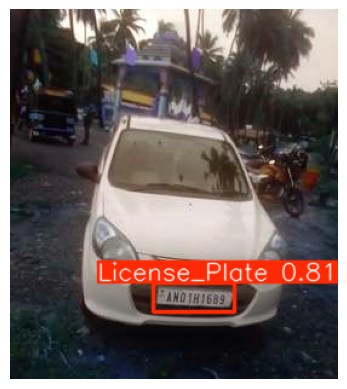

In [8]:
results = model(image_path)

for r in results:
    img = r.plot()   # draws boxes automatically

    import matplotlib.pyplot as plt
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [ ]:
import cv2
from ultralytics import YOLO
import os

model = YOLO(r"D:\Darshan University\Sem-6\MLDL\Project_D_1\runs\detect\plate_detector7\weights\license_plate_best.pt")

output_dir = r"D:\Darshan University\Sem-6\MLDL\Project_D_1\outputs\cropped_plates"
os.makedirs(output_dir, exist_ok=True)

def crop_plate(image_path):

    image = cv2.imread(image_path)
    image_name = os.path.splitext(os.path.basename(image_path))[0]

    results = model(image)

    for r in results:
        boxes = r.boxes.xyxy
        scores = r.boxes.conf

        for i, (box, score) in enumerate(zip(boxes, scores)):

            if score < 0.5:
                continue

            x1, y1, x2, y2 = map(int, box)

            plate = image[y1:y2, x1:x2]

            if plate.size == 0:
                continue

            save_path = os.path.join(output_dir, f"{image_name}_plate_{i}.jpg")

            cv2.imwrite(save_path, plate)

            print(f"Saved: {save_path}")

In [17]:
import os

image_folder = r"D:\Darshan University\Sem-6\MLDL\Project_D_1\dataset_all\images\test"

for img in os.listdir(image_folder):

    crop_plate(os.path.join(image_folder, img))


0: 544x640 1 License_Plate, 343.3ms
Speed: 68.0ms preprocess, 343.3ms inference, 26.2ms postprocess per image at shape (1, 3, 544, 640)
Saved: D:\Darshan University\Sem-6\MLDL\Project_D_1\outputs\cropped_plates\07064c2c-2aa3-4419-91a4-92916de8e54c___mahindra-scorpio-old-car-500x500.jpg_plate_0.jpg

0: 480x640 1 License_Plate, 136.9ms
Speed: 5.2ms preprocess, 136.9ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)
Saved: D:\Darshan University\Sem-6\MLDL\Project_D_1\outputs\cropped_plates\07bd977e-d578-49a2-b345-7cee5a4db6bf___new_1031520d1356604430-skoda-rapid-joins-family-edit-sold-wp_000281.jpg_plate_0.jpg

0: 256x640 1 License_Plate, 80.6ms
Speed: 1.3ms preprocess, 80.6ms inference, 1.2ms postprocess per image at shape (1, 3, 256, 640)
Saved: D:\Darshan University\Sem-6\MLDL\Project_D_1\outputs\cropped_plates\07e787a7-6cc3-482c-9ce5-f0ce115b47f1___new_VW-Polo-GT-TSI-badges-on-the-boot-lid.jpg_plate_0.jpg

0: 480x640 1 License_Plate, 72.4ms
Speed: 3.0ms preprocess, 7

In [ ]:
import easyocr

reader = easyocr.Reader(['en'], gpu=False)  

result = reader.readtext()



In [ ]:
import os
import csv
import cv2
import easyocr

# Initialize OCR reader
reader = easyocr.Reader(['en'], gpu=False)  

image_dir = r"D:\Darshan University\Sem-6\MLDL\Project_D_1\outputs\cropped_plates"
csv_path = r"D:\Darshan University\Sem-6\MLDL\Project_D_1\outputs\ocr_labels.csv"

data = []

for img_name in os.listdir(image_dir):
    if not img_name.lower().endswith((".jpg", ".png")):
        continue

    img_path = os.path.join(image_dir, img_name)

    image = cv2.imread(img_path)

    # OCR detection
    results = reader.readtext(image)

    if len(results) == 0:
        print(f"No text detected: {img_name}")
        continue

    # Get best result (highest confidence)
    best_text = max(results, key=lambda x: x[2])[1]


    best_text = best_text.upper()
    best_text = "".join(filter(str.isalnum, best_text))

    print(f"{img_name} → {best_text}")

    data.append([img_name, best_text])


# Save CSV
with open(csv_path, mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["image_name", "text"])
    writer.writerows(data)

print(" CSV Generated:", csv_path)

Using CPU. Note: This module is much faster with a GPU.
c:\Users\DELL\anaconda3\envs\yolov8_env\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


07064c2c-2aa3-4419-91a4-92916de8e54c___mahindra-scorpio-old-car-500x500.jpg_plate_0.jpg → CP
07bd977e-d578-49a2-b345-7cee5a4db6bf___new_1031520d1356604430-skoda-rapid-joins-family-edit-sold-wp_000281.jpg_plate_0.jpg → MH12JC2813
07e787a7-6cc3-482c-9ce5-f0ce115b47f1___new_VW-Polo-GT-TSI-badges-on-the-boot-lid.jpg_plate_0.jpg → MH14DT8831
07f6d77a-652e-4885-8520-6d405d2f712f___3e7fd381-0ae5-4421-8a70-279ee0ec1c61_840539077_1_1080x720_nissan-terrano-xl-d-thp-110-ps-2016-diesel-_plate_0.jpg → UPSOAS4535
10c96324-3452-43e2-aa68-c8ae7d3c1b6e___844874771_1_1080x720_maruti-suzuki-wagon-r-vxi-bs-iii-2014-petrol-.jpg_plate_0.jpg → T452U1580
175ff546-0679-4cbb-ab03-acfcd96877b7___Maruti_Wagon_R_Rear.jpg_plate_0.jpg → MH06AW8929
18f2e55e-0724-4eee-a28e-5d552a5aa045___20455d0e2dca458f13fbf4da5a2dc118.jpg - Copy_plate_0.jpg → 6786
1e7151e6-8626-4fb2-b7e8-0fb6a8fde713___3e7fd381-0ae5-4421-8a70-279ee0ec1c61_a19be5870f8f2593c994c465a691477e_555X416_1_plate_0.jpg → RI27TC05J0
2153dfcb-5968-4bfc-86ba-7ee

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.



0: 576x640 1 License_Plate, 145.9ms
Speed: 46.8ms preprocess, 145.9ms inference, 1.3ms postprocess per image at shape (1, 3, 576, 640)


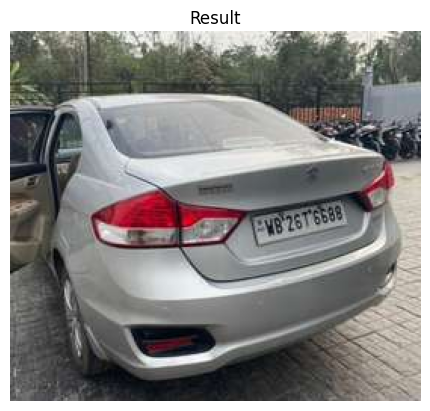

In [ ]:
#EasyOCR

import matplotlib.pyplot as plt
import cv2
import easyocr
from ultralytics import YOLO
import re

# Load models
model = YOLO(r"D:\Darshan University\Sem-6\MLDL\Project_D_1\runs\detect\plate_detector7\weights\license_plate_best.pt")
reader = easyocr.Reader(['en'])

def preprocess_plate(plate):
    gray = cv2.cvtColor(plate, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (3,3), 0)
    _, thresh = cv2.threshold(blur, 150, 255, cv2.THRESH_BINARY)
    return thresh

def clean_text(text):
    text = text.upper()
    text = re.sub(r'[^A-Z0-9]', '', text)
    return text

# Test image
img = cv2.imread(r"D:\Darshan University\Sem-6\MLDL\Project_D_1\dataset_all\images\test\WB1.jpg")

results = model(img)

for r in results:
    boxes = r.boxes.xyxy.cpu().numpy()

    for box in boxes:
        x1, y1, x2, y2 = map(int, box)

        plate = img[y1:y2, x1:x2]

        plate = preprocess_plate(plate)

        ocr_result = reader.readtext(plate)

        for (_, text, prob) in ocr_result:
            text = clean_text(text)

            print("Plate:", text, "Confidence:", prob)

            cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
            cv2.putText(img, text, (x1, y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

# cv2.imshow("Result", img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()


# Convert BGR → RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Result")
plt.axis("off")
plt.show()


In [16]:
ocr_result = reader.readtext(plate, detail=1, paragraph=False)

In [17]:
import re

def clean_text(text):
    text = text.upper()

    # Remove unwanted characters
    text = re.sub(r'[^A-Z0-9]', '', text)

    # Fix common OCR mistakes
    text = text.replace('O', '0')  # O → 0
    text = text.replace('I', '1')  # I → 1
    text = text.replace('Z', '2')  # Z → 2
    text = text.replace('S', '5')  # S → 5

    return text


def is_valid_plate(text):
    pattern = r'^[A-Z]{2}[0-9]{2}[A-Z]{1,2}[0-9]{4}$'
    return re.match(pattern, text)


def extract_plate_text(ocr_result):
    texts = [item[1] for item in ocr_result]

    combined = "".join(texts)
    combined = clean_text(combined)

    return combined

In [18]:
for r in results:
    boxes = r.boxes.xyxy.cpu().numpy()

    for box in boxes:
        x1, y1, x2, y2 = map(int, box)

        plate = img[y1:y2, x1:x2]
        plate = preprocess_plate(plate)

        ocr_result = reader.readtext(plate)

        plate_text = extract_plate_text(ocr_result)

        if is_valid_plate(plate_text):
            print("Valid Plate:", plate_text)
        else:
            print("Raw OCR:", plate_text)

        # Draw
        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(img, plate_text, (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

Raw OCR: 


In [ ]:
import easyocr
import cv2
import os
import re

reader = easyocr.Reader(['en'])

folder = r"D:\Darshan University\Sem-6\MLDL\Project_D_1\outputs\cropped_plates"

def preprocess_plate(plate):
    gray = cv2.cvtColor(plate, cv2.COLOR_BGR2GRAY)
    gray = cv2.equalizeHist(gray)
    plate = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    return plate

def clean_text(text):
    text = text.upper()
    text = re.sub(r'[^A-Z0-9]', '', text)
    return text

results = []

for file in os.listdir(folder):
    path = os.path.join(folder, file)

    img = cv2.imread(path)

    if img is None:
        continue

    processed = preprocess_plate(img)

    ocr_result = reader.readtext(processed)

    text = ""
    for (_, t, prob) in ocr_result:
        if prob > 0.4:
            text += t

    text = clean_text(text)

    print(f"{file} → {text}")

    results.append((file, text))

print("\nFinal Results:", results)

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
c:\Users\DELL\anaconda3\envs\yolov8_env\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


07064c2c-2aa3-4419-91a4-92916de8e54c___mahindra-scorpio-old-car-500x500.jpg_plate_0.jpg → 9052
07bd977e-d578-49a2-b345-7cee5a4db6bf___new_1031520d1356604430-skoda-rapid-joins-family-edit-sold-wp_000281.jpg_plate_0.jpg → HH12JC2813
07e787a7-6cc3-482c-9ce5-f0ce115b47f1___new_VW-Polo-GT-TSI-badges-on-the-boot-lid.jpg_plate_0.jpg → MH14DT8831
07f6d77a-652e-4885-8520-6d405d2f712f___3e7fd381-0ae5-4421-8a70-279ee0ec1c61_840539077_1_1080x720_nissan-terrano-xl-d-thp-110-ps-2016-diesel-_plate_0.jpg → 
10c96324-3452-43e2-aa68-c8ae7d3c1b6e___844874771_1_1080x720_maruti-suzuki-wagon-r-vxi-bs-iii-2014-petrol-.jpg_plate_0.jpg → 
175ff546-0679-4cbb-ab03-acfcd96877b7___Maruti_Wagon_R_Rear.jpg_plate_0.jpg → M406AW8929
18f2e55e-0724-4eee-a28e-5d552a5aa045___20455d0e2dca458f13fbf4da5a2dc118.jpg - Copy_plate_0.jpg → 89HP6786
1e7151e6-8626-4fb2-b7e8-0fb6a8fde713___3e7fd381-0ae5-4421-8a70-279ee0ec1c61_a19be5870f8f2593c994c465a691477e_555X416_1_plate_0.jpg → 
2153dfcb-5968-4bfc-86ba-7ee8ec2d25b1___163231d1425

In [ ]:
import cv2
import torch
import easyocr
import numpy as np
from datetime import datetime
import os

YOLO_MODEL_PATH = r"D:\Darshan University\Sem-6\MLDL\Project_D_1\runs\detect\plate_detector7\weights\license_plate_best.pt"   # your trained YOLO model
OUTPUT_DIR = r"D:\Darshan University\Sem-6\MLDL\Project_D_1\outputs"
LOG_FILE = r"D:\Darshan University\Sem-6\MLDL\Project_D_1\outputs\plate_logs.txt"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Loading models...")
yolo_model = torch.hub.load('ultralytics/yolov8', 'custom', path=YOLO_MODEL_PATH, force_reload=False)
reader = easyocr.Reader(['en'])
print("Models loaded successfully!")

def extract_text(image):
    results = reader.readtext(image)
    text = ""

    for res in results:
        text += res[1] + " "

    return text.strip()

def process_frame(frame):
    results = yolo_model(frame)
    detections = results.xyxy[0]

    plates = []

    for *box, conf, cls in detections:
        x1, y1, x2, y2 = map(int, box)

        plate_img = frame[y1:y2, x1:x2]
        text = extract_text(plate_img)

        plates.append(text)

        # Draw bounding box
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(frame, text, (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

        # Save cropped plate
        filename = f"{OUTPUT_DIR}/{datetime.now().timestamp()}.jpg"
        cv2.imwrite(filename, plate_img)

        # Log
        log_plate(text)

    return frame, plates

def log_plate(text):
    if text == "":
        return

    with open(LOG_FILE, "a") as f:
        f.write(f"{datetime.now()} - {text}\n")

def process_image(image_path):
    frame = cv2.imread(image_path)

    output_frame, plates = process_frame(frame)

    cv2.imshow("Result", output_frame)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    print("Detected Plates:", plates)

def process_video(video_path):
    cap = cv2.VideoCapture(video_path)

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        output_frame, plates = process_frame(frame)

        cv2.imshow("Video ANPR", output_frame)

        if cv2.waitKey(1) & 0xFF == 27:  # ESC key
            break

    cap.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    mode = input("Enter mode (image/video): ").strip()

    if mode == "image":
        path = input("Enter image path: ")
        process_image(path)

    elif mode == "video":
        path = input("Enter video path: ")
        process_video(path)

    else:
        print("Invalid mode selected!")